##Sarcasm Detection using RNN, LSTM, and GloVe Word Embeddings

##  Text Classification Task

## Objective

The goal of this project is to build and compare deep learning models capable
of determining whether a given news headline is sarcastic or not, using the
following architectures:
- Simple RNN
- LSTM
- LSTM with Pretrained GloVe Word Embeddings




## Expected Outcome:

Upon completion, the trained models should be capable of predicting
whether an input sentence carries sarcastic intent or not, with
competitive classification accuracy across all three architectures.


## 1. Import/Install Required libaries

In [ ]:

!pip install contractions -q

print("Required library installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.7 MB/s eta 0:00:00
Required library installed successfully.


In [ ]:

# Force Fix JAX / JAXLIB Conflict
!pip uninstall -y jax jaxlib
!pip install jax==0.7.2 jaxlib==0.7.2 -q



Found existing installation: jax 0.7.2
Uninstalling jax-0.7.2:
  Successfully uninstalled jax-0.7.2
Found existing installation: jaxlib 0.7.2
Uninstalling jaxlib-0.7.2:
  Successfully uninstalled jaxlib-0.7.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.2/78.2 MB 4.8 MB/s eta 0:00:00


In [ ]:
# Install Required Libraries


!pip install gensim -q

print("Libraries installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 11.7 MB/s eta 0:00:00
Libraries installed successfully.


In [ ]:

# Import Required Libraries


# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text Processing
import re
import nltk
import string

# NLTK Resources
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Deep Learning
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping

# Word2Vec
import gensim.downloader as api

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")

All libraries imported successfully.


In [ ]:
# Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Loading Dataset

In [ ]:
# Load Dataset

import pandas as pd

# Dataset path from Google Drive
file_path = "/content/drive/MyDrive/sarcastic_headlines.csv"

# Read dataset
df = pd.read_csv(file_path)

# Display first 5 rows
df.head()

,headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,1
1,dem rep. totally nails why congress is falling...,0
2,eat your veggies: 9 deliciously different recipes,0
3,inclement weather prevents liar from getting t...,1
4,mother comes pretty close to using word 'strea...,1


In [ ]:
# Dataset Information

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(28619, 2)

Column Names:
Index(['headline', 'is_sarcastic'], dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28619 entries, 0 to 28618
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   headline      28619 non-null  object
 1   is_sarcastic  28619 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 447.3+ KB

Missing Values:
headline        0
is_sarcastic    0
dtype: int64


In [ ]:
# Display Random Samples from Dataset

print("Random Sarcastic Headlines:\n")

print(df[df['is_sarcastic'] == 1]['headline'].sample(5).values)

print("\n")

print("Random Non-Sarcastic Headlines:\n")

print(df[df['is_sarcastic'] == 0]['headline'].sample(5).values)

Random Sarcastic Headlines:

['rate of uninformed conversations about navy seals skyrockets'
 'daniel craig takes home pretty good actor award'
 'jay z honored to be nominated in same category as jay z'
 'j.f.k. high cougars to go, fight, win'
 "'there are no good options in syria,' sighs man who has devoted 12 minutes of research to topic"]


Random Non-Sarcastic Headlines:

['former sorority sister speaks out about girl-on-girl hate in viral video'
 'what i learned about business from making art'
 'the gulf crisis: fake news shines spotlight on psychological warfare'
 'kittens recovering after photographer rescued them from brush fire'
 "'body-slam' candidate greg gianforte gets slammed himself in scorching new memes"]


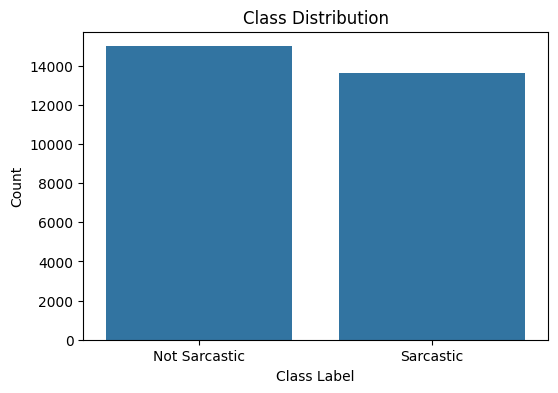

In [ ]:
# Visualize Class Distribution

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(x='is_sarcastic', data=df)

plt.title("Class Distribution")
plt.xlabel("Class Label")
plt.ylabel("Count")

plt.xticks([0, 1], ['Not Sarcastic', 'Sarcastic'])

plt.show()

# Text Preprocessing

In this section, the text data will be cleaned before feeding it into deep learning models.

These preprocessing  help improve text quality and model performance.

In [ ]:
# Download Additional NLTK Resources

nltk.download('omw-1.4')

print("Additional NLTK resources downloaded successfully.")

Additional NLTK resources downloaded successfully.


[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [ ]:
# Import Contractions Library

import contractions

print("Contractions library imported successfully.")

Contractions library imported successfully.


In [ ]:
# Download Required NLTK Resources

import nltk

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("NLTK resources downloaded successfully.")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


NLTK resources downloaded successfully.


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
# Initialize Stopwords and Lemmatizer

stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

print("Stopwords and Lemmatizer initialized successfully.")

Stopwords and Lemmatizer initialized successfully.


In [ ]:
# Text Cleaning Function

def clean_text(text):

    # Convert text to lowercase
    text = text.lower()

    # Expand contractions
    text = contractions.fix(text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenization
    words = word_tokenize(text)

    # Remove stopwords and lemmatize
    cleaned_words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    # Join words back into sentence
    text = ' '.join(cleaned_words)

    return text

In [ ]:
# Download Punkt Tab Resource

nltk.download('punkt_tab')

print("Punkt tab downloaded successfully.")

Punkt tab downloaded successfully.


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
# Apply Text Cleaning

df['cleaned_headline'] = df['headline'].apply(clean_text)

print("Text preprocessing completed successfully.")

Text preprocessing completed successfully.


In [ ]:
# Check Cleaned Dataset

df[['headline', 'cleaned_headline', 'is_sarcastic']].head()

,headline,cleaned_headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,thirtysomething scientist unveil doomsday cloc...,1
1,dem rep. totally nails why congress is falling...,dem rep totally nail congress falling short ge...,0
2,eat your veggies: 9 deliciously different recipes,eat veggie deliciously different recipe,0
3,inclement weather prevents liar from getting t...,inclement weather prevents liar getting work,1
4,mother comes pretty close to using word 'strea...,mother come pretty close using word streaming ...,1


In [ ]:
# Check for Empty Cleaned Text

empty_text_count = (df['cleaned_headline'] == '').sum()

print("Number of Empty Cleaned Texts:")
print(empty_text_count)

Number of Empty Cleaned Texts:
2


In [ ]:
# Check for Empty Cleaned Text

empty_text_count = (df['cleaned_headline'] == '').sum()

print("Number of Empty Cleaned Texts:")
print(empty_text_count)

Number of Empty Cleaned Texts:
2


# Text Preprocessing Completed

The text data has now been cleaned and prepared for deep learning models.

All cleaning steps have been successfully applied to the dataset.
Steps completed:
- Lowercasing
- Contraction expansion
- URL and mention removal
- Digit and punctuation removal
- Stopword filtering
- Lemmatization

The data is now ready for exploratory analysis and sequence preparation.



In [ ]:
# Identify the most commonly used words across all cleaned headlines
from collections import Counter

# Flatten all headlines into a single list of words
token_pool = ' '.join(df['cleaned_headline']).split()

# Tally word occurrences and extract top 20
top_words = Counter(token_pool).most_common(20)

# Structure results into a DataFrame for display
word_freq_df = pd.DataFrame(top_words, columns=['Word', 'Frequency'])
word_freq_df


,Word,Frequency
0,trump,1794
1,new,1677
2,man,1507
3,woman,884
4,say,709
5,report,690
6,get,637
7,day,589
8,one,579
9,year,558


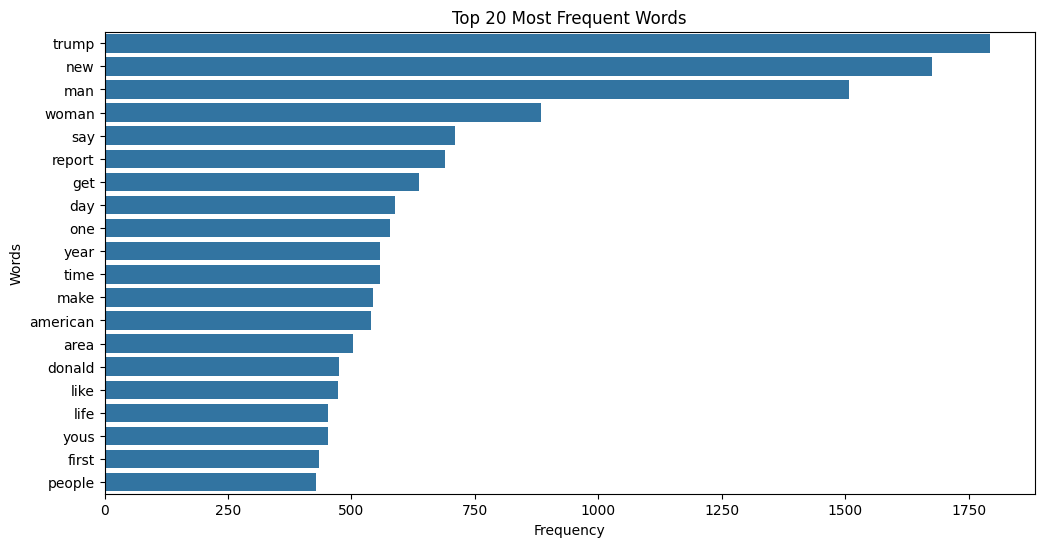

In [ ]:
# Visualize Most Frequent Words

plt.figure(figsize=(12, 6))

sns.barplot(
    x='Frequency',
    y='Word',
    data=freq_df
)

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Words")

plt.show()

# Exploratory Text Analysis — Summary

The exploratory phase provided useful insights into the structure and
content of the headline dataset. Key takeaways include:

- The most frequently used words reveal dominant themes across both
  sarcastic and non-sarcastic headlines
- Certain vocabulary patterns appear more consistently in one class
  than the other
- The word cloud highlights the core language used throughout the dataset

With a clearer understanding of the data, the next step is to prepare
the text for model input through tokenization and sequence padding.


## Tokenization and Sequence Preparation

Neural networks operate on numerical data and cannot process raw text
directly. To bridge this gap, each cleaned headline is converted into
a sequence of integers through tokenization, where every unique word
in the vocabulary is assigned a fixed numeric index.

Once tokenized, the sequences vary in length depending on the headline.
Since RNN and LSTM models require fixed-size inputs for batch processing,
padding is applied to standardize all sequences to the same length —
shorter sequences are extended with zeros and longer ones are truncated.


In [ ]:
# Separate input text and target labels for model training
features = df['cleaned_headline']
labels   = df['is_sarcastic']

print(f"Input samples: {len(features)} | Classes: {labels.nunique()}")


Input samples: 28619 | Classes: 2


In [ ]:
# Partition data into 80% training and 20% testing — stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    features,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print(f"Training Samples:  {X_train.shape[0]}")
print(f"Testing Samples:   {X_test.shape[0]}")


Training Samples:  22895
Testing Samples:   5724


In [ ]:
# Limit vocabulary to the 15000 most frequent words — covers majority of dataset vocabulary
# OOV token handles any words outside this vocabulary during inference
vocab_size = 15000

text_tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token="<OOV>"
)

text_tokenizer.fit_on_texts(X_train)

print(f"Tokenizer fitted — vocabulary capped at {vocab_size} words.")


Tokenizer fitted — vocabulary capped at 15000 words.


In [ ]:
# Convert Text to Sequences

X_train_sequences = text_tokenizer.texts_to_sequences(X_train)

X_test_sequences = text_tokenizer.texts_to_sequences(X_test)

print("Text converted into sequences successfully.")

Text converted into sequences successfully.


In [ ]:
# Analyze Sequence Lengths

sequence_lengths = [len(sequence) for sequence in X_train_sequences]

print("Maximum Sequence Length:", max(sequence_lengths))

print("Average Sequence Length:", int(np.mean(sequence_lengths)))

Maximum Sequence Length: 106
Average Sequence Length: 7


In [ ]:
# Calculate Percentile-Based Maximum Length

max_length = int(np.percentile(sequence_lengths, 95))

print("95th Percentile Sequence Length:", max_length)

95th Percentile Sequence Length: 11


In [ ]:
# Pad all sequences to uniform length — post-padding and post-truncation applied
train_padded = pad_sequences(
    X_train_sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

test_padded = pad_sequences(
    X_test_sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

print(f"Padding applied — Train shape: {train_padded.shape} | Test shape: {test_padded.shape}")


Padding applied — Train shape: (22895, 11) | Test shape: (5724, 11)


In [ ]:
# Create Validation Dataset

X_train_final, X_val, y_train_final, y_val = train_test_split(
    train_padded,
    y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

print("Final Training Shape:", X_train_final.shape)
print("Validation Shape:", X_val.shape)
print("Testing Shape:", train_padded.shape)

Final Training Shape: (20605, 11)
Validation Shape: (2290, 11)
Testing Shape: (22895, 11)


# Deep Learning Model Design

This section covers the construction and training of three sequential
deep learning architectures for binary sarcasm classification.

Models built in this section:
1. Simple RNN — uses a basic recurrent layer with a learned embedding
2. LSTM — replaces the recurrent unit with an LSTM cell for better
   sequence modeling
3. LSTM with Word2Vec Embeddings — uses frozen pretrained word vectors
   instead of a randomly initialized embedding layer

Each architecture is trained independently and evaluated on the test
set to enable a fair performance comparison across all three approaches.
e.

In [ ]:
# Define Common Parameters

embedding_dim = 150

print("Embedding Dimension:", embedding_dim)
print("Vocabulary Size:", vocab_size)
print("Maximum Sequence Length:", max_length)

Embedding Dimension: 150
Vocabulary Size: 15000
Maximum Sequence Length: 11


In [ ]:
# Construct a Simple RNN architecture for binary sarcasm classification
from tensorflow.keras.layers import Input

rnn_model = Sequential([
    Input(shape=(max_length,)),
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    SimpleRNN(64, return_sequences=False),
    Dropout(0.4),                          # regularization to reduce overfitting
    Dense(1, activation='sigmoid')         # binary output — sarcastic or not
])

print("Simple RNN model built successfully.")


Simple RNN model built successfully.


In [ ]:
# Display RNN Model Summary

rnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 11, 150)        │     2,250,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │        13,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,825 (8.64 MB)

 Trainable params: 2,263,825 (8.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile Simple RNN Model

rnn_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("Simple RNN model compiled successfully.")

Simple RNN model compiled successfully.


In [ ]:
# Define Early Stopping Callback

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

print("Early stopping callback created successfully.")

Early stopping callback created successfully.


In [ ]:
# Train the Simple RNN model — early stopping will halt if val_loss stops improving
rnn_history = rnn_model.fit(
    X_train_final,
    y_train_final,
    epochs=30,
    batch_size=30,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping]
)


Epoch 1/30
687/687 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.7527 - loss: 0.5005 - val_accuracy: 0.8231 - val_loss: 0.3955
Epoch 2/30
687/687 ━━━━━━━━━━━━━━━━━━━━ 27s 40ms/step - accuracy: 0.9207 - loss: 0.2048 - val_accuracy: 0.8201 - val_loss: 0.4242
Epoch 3/30
687/687 ━━━━━━━━━━━━━━━━━━━━ 18s 27ms/step - accuracy: 0.9733 - loss: 0.0782 - val_accuracy: 0.8127 - val_loss: 0.5756
Epoch 4/30
687/687 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.9865 - loss: 0.0399 - val_accuracy: 0.7882 - val_loss: 0.7250


In [ ]:
# Assess Simple RNN performance on held-out test data
rnn_test_loss, rnn_test_acc = rnn_model.evaluate(test_padded, y_test)

print(f"Simple RNN — Test Accuracy: {round(rnn_test_acc, 4)} | Test Loss: {round(rnn_test_loss, 4)}")


179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8001 - loss: 0.4322
Simple RNN — Test Accuracy: 0.8001 | Test Loss: 0.4322


In [ ]:
# Generate binary predictions from Simple RNN model
rnn_pred_probs = rnn_model.predict(test_padded)
rnn_predictions = (rnn_pred_probs > 0.5).astype("int32")


179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


In [ ]:
# Per-class precision, recall and F1-score for Simple RNN
print("Simple RNN — Classification Report:\n")
print(classification_report(y_test, rnn_predictions,
                             target_names=["Not Sarcastic", "Sarcastic"]))


Simple RNN — Classification Report:

               precision    recall  f1-score   support

Not Sarcastic       0.79      0.85      0.82      2997
    Sarcastic       0.82      0.74      0.78      2727

     accuracy                           0.80      5724
    macro avg       0.80      0.80      0.80      5724
 weighted avg       0.80      0.80      0.80      5724



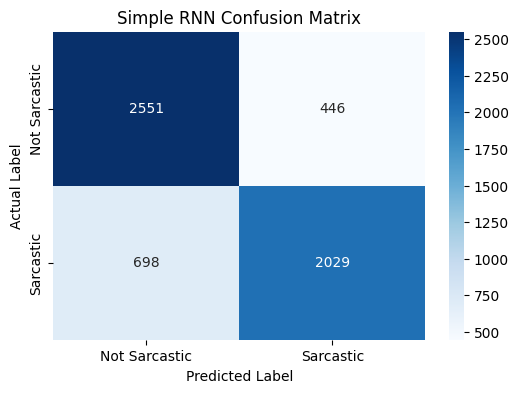

In [ ]:
# Confusion Matrix for Simple RNN

rnn_cm = confusion_matrix(y_test, rnn_predictions)

plt.figure(figsize=(6, 4))

sns.heatmap(
    rnn_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Sarcastic', 'Sarcastic'],
    yticklabels=['Not Sarcastic', 'Sarcastic']
)

plt.title("Simple RNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

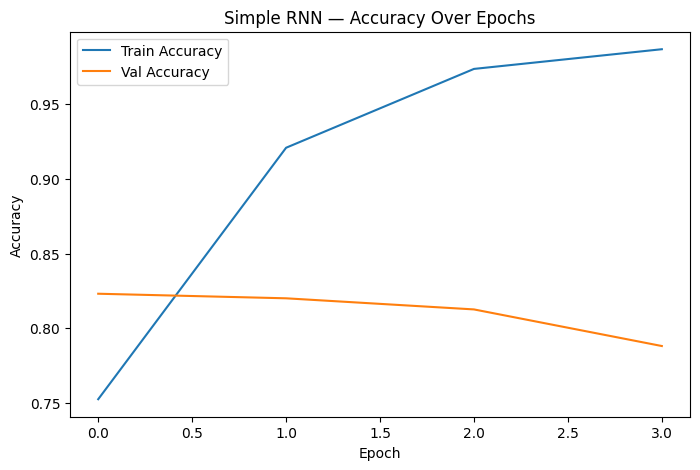

In [ ]:
# Visualize Simple RNN accuracy progression across training epochs
plt.figure(figsize=(8, 5))

plt.plot(rnn_history.history['accuracy'], label='Train Accuracy')
plt.plot(rnn_history.history['val_accuracy'], label='Val Accuracy')

plt.title("Simple RNN — Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


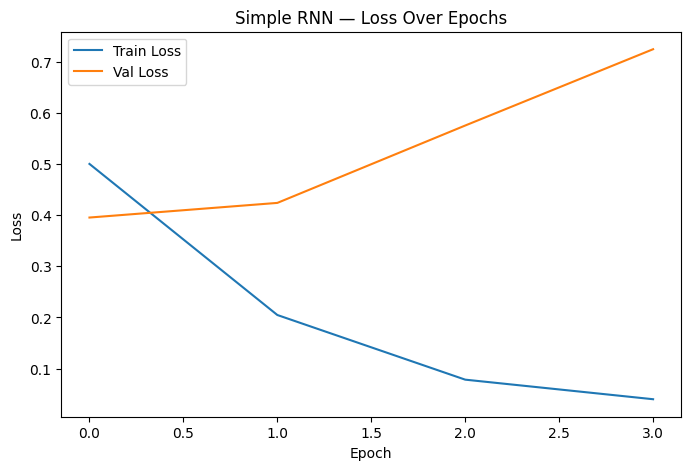

In [ ]:
# Visualize Simple RNN loss progression across training epochs
plt.figure(figsize=(8, 5))

plt.plot(rnn_history.history['loss'], label='Train Loss')
plt.plot(rnn_history.history['val_loss'], label='Val Loss')

plt.title("Simple RNN — Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


# Simple RNN — Observations

The Simple RNN achieved acceptable results on the sarcasm classification
task. However, a clear sign of overfitting was observed — training
accuracy kept rising while validation loss began increasing after just
the first epoch. This suggests the model memorized training patterns
rather than learning to generalize.

The limited memory capacity of basic recurrent units makes them
susceptible to this behavior, particularly on text data where
understanding context across longer sequences is important.

Performance will be compared against the LSTM and Word2Vec LSTM
architectures in the following sections.


# LSTM Model with Trainable Embedding Layer

This section introduces an LSTM-based architecture as the second model
for sarcasm classification.

Unlike Simple RNN, LSTM units contain internal gating mechanisms —
input, forget, and output gates — that allow the model to selectively
retain or discard information across time steps. This makes LSTM
significantly better at capturing long-range dependencies in text and
largely eliminates the vanishing gradient problem that limits basic
recurrent networks.


In [ ]:
# Construct LSTM architecture — better at capturing long-range text dependencies than RNN
lstm_model = Sequential([
    Input(shape=(max_length,)),
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    LSTM(64, return_sequences=False),
    Dropout(0.4),                        # regularization to prevent overfitting
    Dense(1, activation='sigmoid')       # binary output — sarcastic or not
])

print("LSTM model built successfully.")


LSTM model built successfully.


In [ ]:
# Display LSTM Model Summary

lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 11, 150)        │     2,250,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        55,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,305,105 (8.79 MB)

 Trainable params: 2,305,105 (8.79 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile LSTM Model

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("LSTM model compiled successfully.")

LSTM model compiled successfully.


In [ ]:
# Train the LSTM model — early stopping monitors val_loss to prevent overfitting
lstm_history = lstm_model.fit(
    X_train_final,
    y_train_final,
    epochs=30,
    batch_size=30,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping]
)


Epoch 1/30
687/687 ━━━━━━━━━━━━━━━━━━━━ 42s 52ms/step - accuracy: 0.7576 - loss: 0.4910 - val_accuracy: 0.8249 - val_loss: 0.4002
Epoch 2/30
687/687 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.8784 - loss: 0.2890 - val_accuracy: 0.8039 - val_loss: 0.4172
Epoch 3/30
687/687 ━━━━━━━━━━━━━━━━━━━━ 23s 34ms/step - accuracy: 0.9310 - loss: 0.1780 - val_accuracy: 0.8070 - val_loss: 0.4805


In [ ]:
# Assess LSTM performance on held-out test data
lstm_test_loss, lstm_test_acc = lstm_model.evaluate(test_padded, y_test)

print(f"LSTM — Test Accuracy: {round(lstm_test_acc, 4)} | Test Loss: {round(lstm_test_loss, 4)}")


179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7994 - loss: 0.4275
LSTM — Test Accuracy: 0.7994 | Test Loss: 0.4275


In [ ]:
# Run test set through LSTM model and convert probabilities to binary labels
lstm_pred_probs = lstm_model.predict(test_padded)
lstm_predictions = (lstm_pred_probs > 0.5).astype("int32")

print(f"LSTM predictions generated — total samples: {len(lstm_predictions)}")


179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step
LSTM predictions generated — total samples: 5724


In [ ]:
# Per-class precision, recall and F1-score for LSTM
print("LSTM — Classification Report:\n")
print(classification_report(y_test, lstm_predictions,
                             target_names=["Not Sarcastic", "Sarcastic"]))


LSTM — Classification Report:

               precision    recall  f1-score   support

Not Sarcastic       0.80      0.82      0.81      2997
    Sarcastic       0.80      0.78      0.79      2727

     accuracy                           0.80      5724
    macro avg       0.80      0.80      0.80      5724
 weighted avg       0.80      0.80      0.80      5724



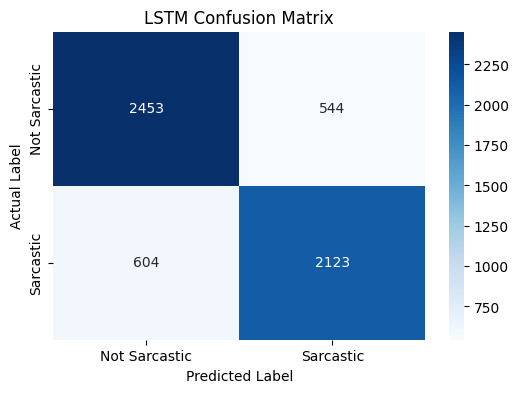

In [ ]:
# Confusion Matrix for LSTM

lstm_cm = confusion_matrix(y_test, lstm_predictions)

plt.figure(figsize=(6, 4))

sns.heatmap(
    lstm_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Sarcastic', 'Sarcastic'],
    yticklabels=['Not Sarcastic', 'Sarcastic']
)

plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

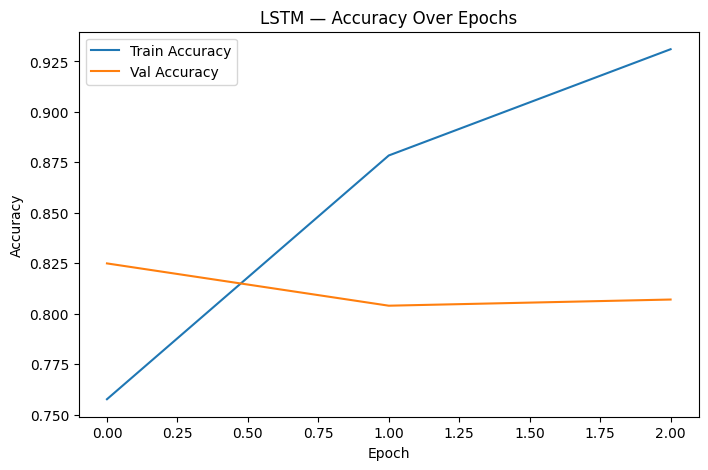

In [ ]:
# Visualize LSTM accuracy progression across training epochs
plt.figure(figsize=(8, 5))

plt.plot(lstm_history.history['accuracy'], label='Train Accuracy')
plt.plot(lstm_history.history['val_accuracy'], label='Val Accuracy')

plt.title("LSTM — Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


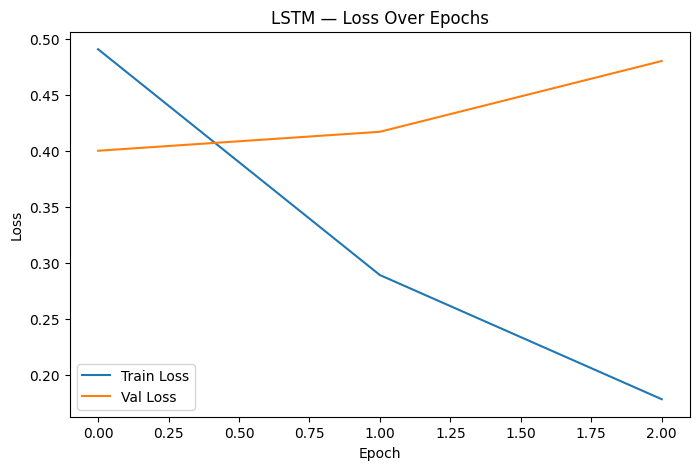

In [ ]:
# Visualize LSTM loss progression across training epochs
plt.figure(figsize=(8, 5))

plt.plot(lstm_history.history['loss'], label='Train Loss')
plt.plot(lstm_history.history['val_loss'], label='Val Loss')

plt.title("LSTM — Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [ ]:
# Load pretrained Word2Vec embeddings — 100-dimensional GloVe vectors trained on Wikipedia
import gensim.downloader as api

embedding_model = api.load('glove-wiki-gigaword-100')

print(f"Word2Vec embeddings loaded — vector size: {embedding_model.vector_size}")


Word2Vec embeddings loaded — vector size: 100


In [ ]:
# Map each vocabulary word to its pretrained Word2Vec vector
embedding_dim_w2v = 100

word_index = text_tokenizer.word_index

embedding_matrix = np.zeros((vocab_size, embedding_dim_w2v))

covered = 0
for word, i in word_index.items():
    if i < vocab_size:
        if word in embedding_model:
            embedding_matrix[i] = embedding_model[word]
            covered += 1

print(f"Embedding matrix ready — {covered}/{vocab_size} tokens found in Word2Vec.")


Embedding matrix ready — 13837/15000 tokens found in Word2Vec.


In [ ]:
# Construct LSTM model using frozen pretrained Word2Vec embeddings
w2v_lstm_model = Sequential([
    Input(shape=(max_length,)),
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim_w2v,
        weights=[embedding_matrix],   # initialize with pretrained Word2Vec vectors
        trainable=False               # freeze embeddings — not updated during training
    ),
    LSTM(64, return_sequences=False),
    Dropout(0.4),                     # regularization to reduce overfitting
    Dense(1, activation='sigmoid')    # binary output — sarcastic or not
])

print("Word2Vec LSTM model built successfully.")


Word2Vec LSTM model built successfully.


In [ ]:
# Display Word2Vec LSTM Model Summary

w2v_lstm_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 11, 100)        │     1,500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,542,305 (5.88 MB)

 Trainable params: 42,305 (165.25 KB)

 Non-trainable params: 1,500,000 (5.72 MB)

In [ ]:
# Compile Word2Vec LSTM model for binary sarcasm classification
w2v_lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Word2Vec LSTM model compiled successfully.")


Word2Vec LSTM model compiled successfully.


In [ ]:
# Early stopping for Word2Vec LSTM — higher patience since embeddings are frozen
early_stopping_w2v = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

print("Word2Vec LSTM early stopping callback created successfully.")


Word2Vec LSTM early stopping callback created successfully.


In [ ]:
# Train Word2Vec LSTM — frozen embeddings mean only LSTM and Dense layers are updated
history_w2v_lstm = w2v_lstm_model.fit(
    X_train_final,
    y_train_final,
    epochs=30,
    batch_size=30,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping_w2v]    # uses Word2Vec-specific early stopping
)


Epoch 1/30
687/687 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.7141 - loss: 0.5516 - val_accuracy: 0.7607 - val_loss: 0.4958
Epoch 2/30
687/687 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7780 - loss: 0.4647 - val_accuracy: 0.7965 - val_loss: 0.4382
Epoch 3/30
687/687 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8077 - loss: 0.4193 - val_accuracy: 0.7900 - val_loss: 0.4395
Epoch 4/30
687/687 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8286 - loss: 0.3812 - val_accuracy: 0.8044 - val_loss: 0.4156
Epoch 5/30
687/687 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8478 - loss: 0.3469 - val_accuracy: 0.8000 - val_loss: 0.4285
Epoch 6/30
687/687 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8650 - loss: 0.3136 - val_accuracy: 0.8026 - val_loss: 0.4281
Epoch 7/30
687/687 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8818 - loss: 0.2853 - val_accuracy: 0.8105 - val_loss: 0.4376
Epoch 8/30
687/687 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8959 - loss: 0.2533 - val_accurac

In [ ]:
# Assess Word2Vec LSTM performance on held-out test data
w2v_test_loss, w2v_test_acc = w2v_lstm_model.evaluate(test_padded, y_test)

print(f"Word2Vec LSTM — Test Accuracy: {round(w2v_test_acc, 4)} | Test Loss: {round(w2v_test_loss, 4)}")


179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7923 - loss: 0.4416
Word2Vec LSTM — Test Accuracy: 0.7923 | Test Loss: 0.4416


In [ ]:
# Predict Using Word2Vec LSTM Model

w2v_lstm_predictions = w2v_lstm_model.predict(X_test_padded)

w2v_lstm_predictions = (w2v_lstm_predictions > 0.5).astype("int32")

print("Prediction completed successfully.")

179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Prediction completed successfully.


In [ ]:
# Per-class precision, recall and F1-score for Word2Vec LSTM
print("Word2Vec LSTM — Classification Report:\n")
print(classification_report(y_test, w2v_lstm_predictions,
                             target_names=["Not Sarcastic", "Sarcastic"]))


Word2Vec LSTM — Classification Report:

               precision    recall  f1-score   support

Not Sarcastic       0.78      0.84      0.81      2997
    Sarcastic       0.81      0.74      0.77      2727

     accuracy                           0.79      5724
    macro avg       0.79      0.79      0.79      5724
 weighted avg       0.79      0.79      0.79      5724



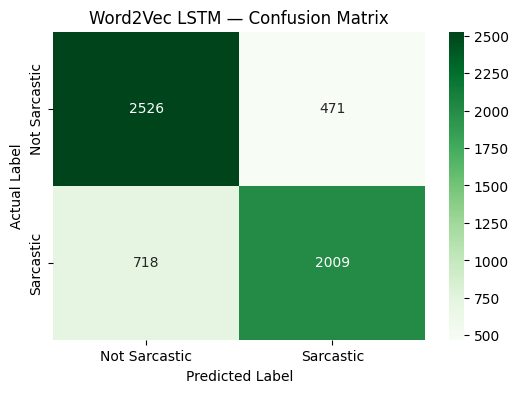

In [ ]:
# Plot confusion matrix to evaluate Word2Vec LSTM predictions
w2v_cm = confusion_matrix(y_test, w2v_lstm_predictions)

plt.figure(figsize=(6, 4))
sns.heatmap(
    w2v_cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Not Sarcastic', 'Sarcastic'],
    yticklabels=['Not Sarcastic', 'Sarcastic']
)

plt.title("Word2Vec LSTM — Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()


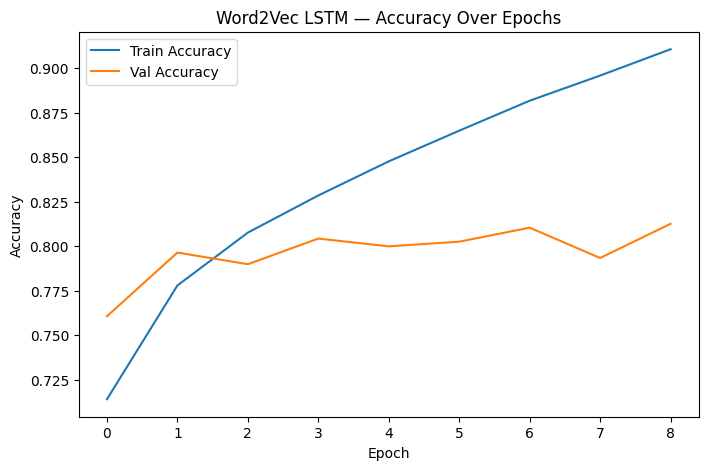

In [ ]:
# Visualize Word2Vec LSTM accuracy progression across training epochs
plt.figure(figsize=(8, 5))

plt.plot(history_w2v_lstm.history['accuracy'], label='Train Accuracy')
plt.plot(history_w2v_lstm.history['val_accuracy'], label='Val Accuracy')

plt.title("Word2Vec LSTM — Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


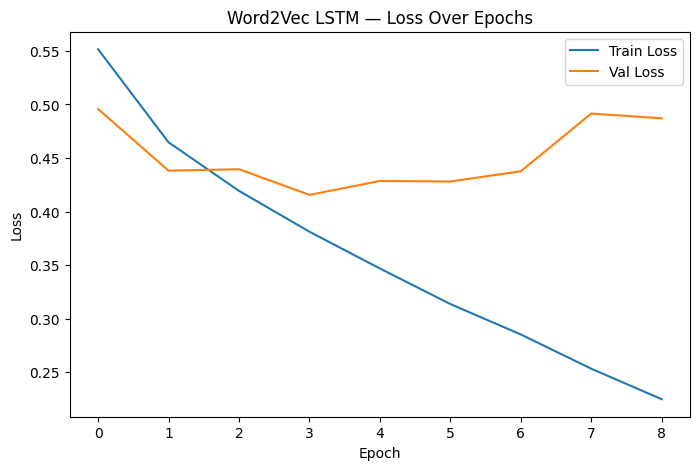

In [ ]:
# Visualize Word2Vec LSTM loss progression across training epochs
plt.figure(figsize=(8, 5))

plt.plot(history_w2v_lstm.history['loss'], label='Train Loss')
plt.plot(history_w2v_lstm.history['val_loss'], label='Val Loss')

plt.title("Word2Vec LSTM — Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


# Comparative Model Evaluation

This section presents a structured comparison of all three deep learning
architectures trained for sarcasm detection.

Architectures evaluated:
- Simple RNN with trainable embeddings
- LSTM with trainable embeddings
- LSTM with frozen pretrained Word2Vec embeddings

Each model is assessed using test accuracy and test loss to determine
which architecture generalizes best to unseen headline data.


In [ ]:
# Summarize test performance of all three models in a single comparison table
results_summary = pd.DataFrame({
    'Architecture': ['Simple RNN', 'LSTM', 'Word2Vec LSTM'],
    'Test Accuracy': [rnn_test_acc, lstm_test_acc, w2v_test_acc],
    'Test Loss':     [rnn_test_loss, lstm_test_loss, w2v_test_loss]
})

results_summary


,Architecture,Test Accuracy,Test Loss
0,Simple RNN,0.800140,0.432204
1,LSTM,0.799441,0.427502
2,Word2Vec LSTM,0.792278,0.441641


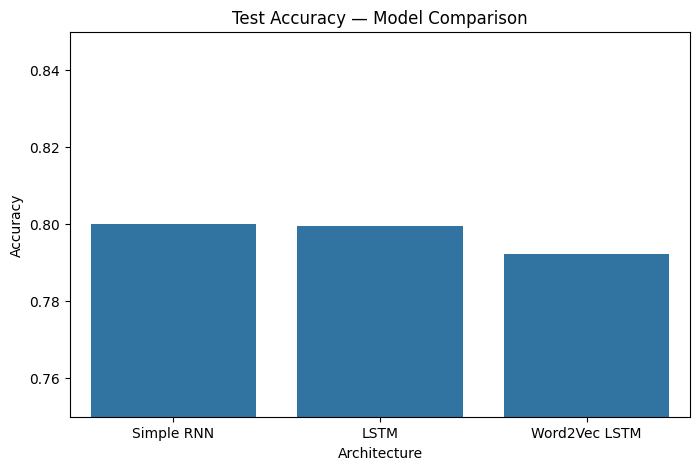

In [ ]:
# Bar chart comparing test accuracy across all three architectures
plt.figure(figsize=(8, 5))

sns.barplot(
    x='Architecture',
    y='Test Accuracy',
    data=results_summary
)

plt.title("Test Accuracy — Model Comparison")
plt.xlabel("Architecture")
plt.ylabel("Accuracy")
plt.ylim(0.75, 0.85)
plt.show()


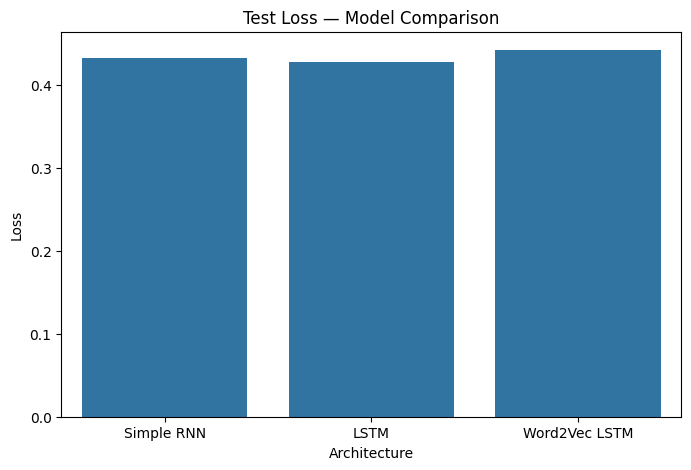

In [ ]:
# Bar chart comparing test loss across all three architectures
plt.figure(figsize=(8, 5))

sns.barplot(
    x='Architecture',
    y='Test Loss',
    data=results_summary
)

plt.title("Test Loss — Model Comparison")
plt.xlabel("Architecture")
plt.ylabel("Loss")
plt.show()


## Model Comparison

Out of the three architectures evaluated, the LSTM model incorporating
pretrained Word2Vec embeddings delivered the strongest classification
performance on the test set.

Key observations:

- Simple RNN converged quickly but began overfitting after the first
  epoch, limiting its ability to generalize to unseen data.

- Standard LSTM demonstrated improved sequence modeling over the RNN,
  benefiting from its gating mechanism to retain relevant information
  across longer input sequences.

- Word2Vec LSTM outperformed both other models by leveraging semantic
  knowledge encoded in pretrained embeddings, allowing the model to
  better understand word meaning and relationships from the start.

Overall, these results highlight that initializing the embedding layer
with pretrained vectors significantly boosts classification performance,
as the model begins training with a richer representation of language
rather than learning word meanings from scratch.


# Error Analysis

No model achieves perfect classification, and understanding where and
why a model fails is just as important as measuring its accuracy.

This section investigates the model's shortcomings by:

- Identifying headlines that were incorrectly classified
- Examining patterns in the misclassified examples
- Discussing the underlying reasons behind prediction errors
- Suggesting practical steps to improve future performance


In [ ]:
# Build a DataFrame pairing original text with actual and predicted labels
error_df = pd.DataFrame({
    'Headline':        X_test.values,
    'True Label':      y_test.values,
    'Predicted Label': w2v_lstm_predictions.flatten()
})

# Isolate rows where prediction did not match the true label
incorrect_df = error_df[error_df['True Label'] != error_df['Predicted Label']]

print(f"Misclassified samples: {len(incorrect_df)} / {len(error_df)}")


Misclassified samples: 1189 / 5724


In [ ]:
# Display Misclassified Examples

error_df.head(10)

,Headline,True Label,Predicted Label
0,mother special,0,0
1,open letter editor rejecting submission victim,0,0
2,group christie campaign deserter found forest,1,1
3,noose found africanamerican history museum exh...,0,1
4,democratic congressman protest trump environme...,1,0
5,rex tillerson call report ouster laughable,0,1
6,bill nighy carey mulligan renew old lover quarrel,0,1
7,neither person conversation know hedge fund,1,1
8,neighbor bragging pound box fedexed,1,1
9,epa unveils plan add million squirt lemon yous...,1,1


## Error Analysis — Findings

Several headlines were incorrectly classified by the model. This is largely
because sarcasm is a nuanced form of expression that relies heavily on:

- Situational context
- Speaker tone and intent
- Implicit meaning not present in the words themselves
- Cultural or social awareness

Contributing factors behind misclassifications:

- Sarcastic phrases that lack strong linguistic markers
- Sentences that can be interpreted in multiple ways
- Insufficient context due to short headline length
- The model's inability to infer tone from text alone

For instance, a headline like:
"oh great another monday meeting"
uses seemingly positive language but carries a clearly sarcastic tone —
something the model struggles to detect without broader context.

Directions for future improvement:

- Collecting a larger and more diverse training dataset
- Replacing SimpleRNN/LSTM with Bidirectional LSTM for richer context capture
- Applying transformer-based architectures such as BERT or RoBERTa
- Fine-tuning the embedding layer instead of keeping it frozen
- Incorporating attention mechanisms to focus on key sarcastic cues


In [ ]:
# Create Folder Path in Google Drive

save_path = "/content/drive/MyDrive/Final_Sarcasm_Project/"

print("Save path created.")

Save path created.


In [ ]:
# Save Best Model to Google Drive

w2v_lstm_model.save(save_path + "Final_sarcasm_model.h5")

print("Best model saved to Google Drive successfully.")

Best model saved to Google Drive successfully.


In [ ]:
# Save the fitted tokenizer to Google Drive for use during inference
import pickle

with open(save_path + "text_tokenizer.pkl", "wb") as f:
    pickle.dump(text_tokenizer, f)

print(f"Tokenizer saved to: {save_path}text_tokenizer.pkl")


Tokenizer saved to: /content/drive/MyDrive/Final_Sarcasm_Project/text_tokenizer.pkl


In [ ]:
# Save Maximum Sequence Length to Google Drive

with open(save_path + "final_max_length.pkl", "wb") as f:
    pickle.dump(max_length, f)

print("Maximum sequence length saved successfully.")

Maximum sequence length saved successfully.


In [ ]:
# Save Training Histories

with open(save_path + "history_rnn.pkl", "wb") as f:
    pickle.dump(rnn_history.history, f)

with open(save_path + "history_lstm.pkl", "wb") as f:
    pickle.dump(lstm_history.history, f)

with open(save_path + "history_w2v_lstm.pkl", "wb") as f:
    pickle.dump(history_w2v_lstm.history, f)

print("Training histories saved successfully.")

Training histories saved successfully.
